<a href="https://colab.research.google.com/github/divya-bisht-personal/coffee-shop-retention/blob/main/FeedMeNYC_Filter%20Importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feed Me NYC: Filter Importance A/B Test
April 2026

### Overview    
This analysis seeks to optimize the user experience of my Feed Me NYC restaurant generator. I wanted to test and compare two versions of the filters on the website: one that would offer filters to generate a restaurant recommendation and another that would allow a user to prioritize their restaurant criteria. The analysis seeks to understand if filter prioritization would result in a higher likelihood of the user actually going to the resulting restaurant (responding "Yes" to the question, "Would you actually go here?" on the result page).

### Data
The data for this project comes from my own website Feed Me NYC (https://feed-me-nyc.netlify.app/), which aims to generate one restaurant recommendation to those who are overwhelmed with the great choices the city has to offer. The data is collected and stored using Google Analytics and exported from BigQuery. The dataset contains 994 rows across 7 event types, collected between 3/8/26 and 4/3/26.

### Hypothesis
Allowing users to prioritize their restaurant filters (Must Have, Prefer, Don't Care) leads to a higher likelihood of them liking the recommendation and selecting "Yes" when asked "Would you actually go here?"

### Assumptions
* Users are randomly assigned to Version A or B on their first visit and remain in that version across sessions
* A user's yes/no response reflects their genuine intent to visit the restaurant
* The 56 users who provided feedback are representative of the broader user base — there is no systematic difference between users who gave feedback and those who did not
* Filter choices are made independently — one user's selections do not influence another's

### Preliminary Results
Despite 100 unique users visiting the website between 3/8/26 and 4/3/26, only 56 users made it to the result page and offered yes or no feedback. The distribution of users between Version A and B was evenly split- 27 for Version A and 29 for Version B. At the event level, however, Version B users generated notably more activity (582 events vs. 412 for Version A), suggesting they may have returned to the site more often or spun for new results repeatedly.

So far, the results show that Version A users said yes 59.3% of the time compared to 48.3% for Version B, a difference of approximately 11 percentage points. This suggests that simpler filters may lead to more satisfying recommendations, though the mechanism is unclear from this data.

I ran two chi-square tests of independence: one where I took the first response for users who completed multiple spins (deduplicated), and one where I included all spins. Both tests were not statistically significant (p-value 0.58 and 0.15, respectively).

The effect size (Cohen's w = 0.04) is very small and a power analysis suggests we'd need roughly 10,740 users offering feedback to detect a difference this size with any confidence. This is assuming that the true effect size wouldn't change with an increased sample size, as 56 users is a small number to estimate off of.

## Loading the Data
Static file from MyDrive downloaded fom BigQuery, where my Google Analytics data warehouse lives. Downloaded file on 4/3/26.

In [3]:
import pandas as pd

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/FeedMeNYC_04.03.26.csv')

## Exploratory Data Analysis

In [6]:
df.head()

,user_pseudo_id,event_timestamp,event_name,variant,cuisine_selected,price_selected,distance_selected,zip_code,result_cuisine,result_price_tier,restaurant_id,spin_number,importance_cuisine,importance_price,importance_subway,filters_changed_from_default
0,1.006636e+09,1773423480336090,filter_start,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.006636e+09,1773423492824730,filter_complete,A,korean,"$,$$",NaN,Union square,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
2,1.006636e+09,1773423498824386,result_view,A,NaN,NaN,NaN,NaN,Korean Restaurant,$$,ChIJidRg2VVZwokRPnHmTPe_oko,NaN,NaN,NaN,NaN,NaN
3,1.006894e+09,1774124546807300,filter_start,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.006894e+09,1774124642684863,filter_complete,A,thai,$$,2.0,11225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0


In [7]:
df.info()
 # filter-related columns (cuisine_selected, price_selected, distance_selected, etc.) have fewer non-null values because they only populate on filter_complete events, not all event types.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_pseudo_id                994 non-null    float64
 1   event_timestamp               994 non-null    int64  
 2   event_name                    994 non-null    object 
 3   variant                       994 non-null    object 
 4   cuisine_selected              153 non-null    object 
 5   price_selected                153 non-null    object 
 6   distance_selected             137 non-null    float64
 7   zip_code                      153 non-null    object 
 8   result_cuisine                286 non-null    object 
 9   result_price_tier             251 non-null    object 
 10  restaurant_id                 518 non-null    object 
 11  spin_number                   175 non-null    float64
 12  importance_cuisine            68 non-null     object 
 13  impor

In [8]:
df.sample(10)

,user_pseudo_id,event_timestamp,event_name,variant,cuisine_selected,price_selected,distance_selected,zip_code,result_cuisine,result_price_tier,restaurant_id,spin_number,importance_cuisine,importance_price,importance_subway,filters_changed_from_default
311,1.782827e+09,1773243606083120,result_view,B,NaN,NaN,NaN,NaN,Korean Restaurant,$$,ChIJ8U5Gf-lbwokRDxfHng9NrNs,NaN,NaN,NaN,NaN,NaN
543,5.034341e+08,1773436498786652,feedback_yes,B,NaN,NaN,NaN,NaN,NaN,NaN,ChIJETquaPVZwokRVYYGSKrg4E0,NaN,NaN,NaN,NaN,NaN
147,1.296165e+09,1773366927603622,result_view,A,NaN,NaN,NaN,NaN,Restaurant,$$,ChIJ-V7NLMxZwokRwWqYU9xL8tQ,NaN,NaN,NaN,NaN,NaN
367,1.924651e+09,1774377105802886,result_view,B,NaN,NaN,NaN,NaN,Fast Food Restaurant,$,ChIJJ-m5wLVOwokRTH5UWxFTE-8,NaN,NaN,NaN,NaN,NaN
31,1.113339e+08,1773155874767084,feedback_yes,B,NaN,NaN,NaN,NaN,NaN,NaN,ChIJCehOSIRYwokRs4ijKsy1oiI,NaN,NaN,NaN,NaN,NaN
839,8.085904e+08,1773084212288500,filter_complete,B,korean,any,2.0,10001,NaN,NaN,NaN,NaN,must,prefer,must,2.0
243,1.595461e+09,1774409432519348,feedback_no,A,NaN,NaN,NaN,NaN,NaN,NaN,ChIJIccpGllZwokRx0BsEyyeQg4,NaN,NaN,NaN,NaN,NaN
179,1.359943e+09,1774316808657484,spin_again,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
668,6.582973e+08,1774305405985847,result_view,B,NaN,NaN,NaN,NaN,Beer Garden,$$,ChIJhQCuY3VbwokRanBob6BoCrI,NaN,NaN,NaN,NaN,NaN
449,3.648606e+08,1773176482180146,result_view,A,NaN,NaN,NaN,NaN,Pizza Restaurant,$$,ChIJs8MdNo9ZwokRTPUHiArLC-o,NaN,NaN,NaN,NaN,NaN


In [9]:
df.variant.value_counts()

,count
variant,
B,582
A,412


In [10]:
# number of unique users across all event types
df.user_pseudo_id.nunique()

100

In [11]:
df.event_name.value_counts()
# result_view is highest because you get an event_id for every spin, not just once per session)
# filter_complete being greater than filter_start shows that some useres skipped using the filters altogether to "Find My Spot"

,count
event_name,
result_view,286
spin_again,175
filter_complete,155
filter_start,146
feedback_yes,110
feedback_no,101
maps_click,21


In [12]:
user_w_repeat_visits = df.user_pseudo_id.value_counts()

In [13]:
user_w_repeat_visits[user_w_repeat_visits>1]

,count
user_pseudo_id,
8.085904e+08,101
1.782827e+09,43
6.582973e+08,43
5.798654e+07,34
1.582676e+09,29
...,...
4.866169e+08,3
4.380025e+08,3
5.190523e+07,3


In [14]:
len(user_w_repeat_visits[user_w_repeat_visits>1])
#86 people visited the site more than once

86

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

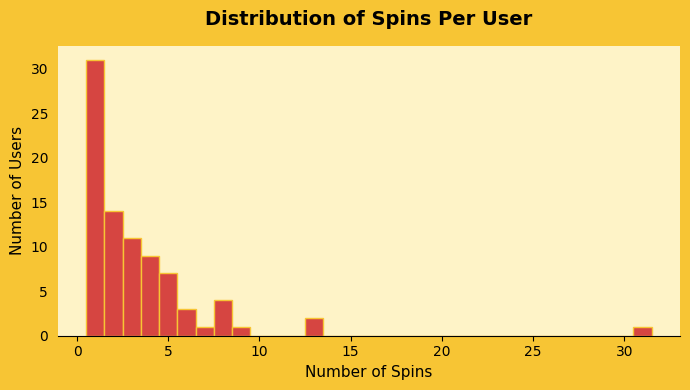

In [16]:
spin_counts = df[df['event_name'] == 'result_view'].groupby('user_pseudo_id').size()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(spin_counts.values, bins=range(1, spin_counts.max()+2),
          color='#D64541', edgecolor='#F7C534', align='left')

ax.set_title('Distribution of Spins Per User', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Spins', fontsize=11)
ax.set_ylabel('Number of Users', fontsize=11)
ax.set_facecolor('#FEF3C7')
fig.patch.set_facecolor('#F7C534')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()


In [17]:
#need to narrow down to only where users reached the feedback yes/no stage
df_feedback = df[df['event_name'].isin(['feedback_yes','feedback_no'])]

In [18]:
df_feedback.sample(10)

,user_pseudo_id,event_timestamp,event_name,variant,cuisine_selected,price_selected,distance_selected,zip_code,result_cuisine,result_price_tier,restaurant_id,spin_number,importance_cuisine,importance_price,importance_subway,filters_changed_from_default
446,3.159102e+08,1773197605785085,feedback_yes,A,NaN,NaN,NaN,NaN,NaN,NaN,ChIJKbKvOwBZwokRE3mEbmx_F6g,NaN,NaN,NaN,NaN,NaN
884,8.863729e+08,1773437674843759,feedback_no,B,NaN,NaN,NaN,NaN,NaN,NaN,ChIJ58OtM8pZwokRbd6DT6gcVys,NaN,NaN,NaN,NaN,NaN
894,8.863729e+08,1773437713815147,feedback_no,B,NaN,NaN,NaN,NaN,NaN,NaN,ChIJKVbn75VZwokRLdlBWe5rbtU,NaN,NaN,NaN,NaN,NaN
786,8.085904e+08,1772922343724201,feedback_yes,B,NaN,NaN,NaN,NaN,NaN,NaN,ChIJSRT5b9ZbwokRYilWRG4jYaY,NaN,NaN,NaN,NaN,NaN
459,3.948727e+08,1773433654051232,feedback_no,B,NaN,NaN,NaN,NaN,NaN,NaN,ChIJ92OsaJVZwokRsC54kf-J-3g,NaN,NaN,NaN,NaN,NaN
571,5.593439e+08,1774125415487815,feedback_yes,A,NaN,NaN,NaN,NaN,NaN,NaN,ChIJpZ8NRydawokRXYCtGefF0Nc,NaN,NaN,NaN,NaN,NaN
981,9.983193e+08,1773264834123476,feedback_no,A,NaN,NaN,NaN,NaN,NaN,NaN,ChIJKSnzQJVewokRme40boVi4uk,NaN,NaN,NaN,NaN,NaN
462,3.948727e+08,1773433661499653,feedback_no,B,NaN,NaN,NaN,NaN,NaN,NaN,ChIJb7P5f9FZwokR2HSsdIIDLls,NaN,NaN,NaN,NaN,NaN
754,8.036466e+08,1773245013121639,feedback_yes,A,NaN,NaN,NaN,NaN,NaN,NaN,ChIJ_85dJlZYwokR29NPLSJngR4,NaN,NaN,NaN,NaN,NaN
66,1.148802e+09,1773195205647906,feedback_yes,B,NaN,NaN,NaN,NaN,NaN,NaN,ChIJCar0f49ZwokR6ozLV-dHNTE,NaN,NaN,NaN,NaN,NaN


In [19]:
df_feedback.event_name.value_counts()

,count
event_name,
feedback_yes,110
feedback_no,101


In [20]:
df_feedback.user_pseudo_id.nunique()

56

In [21]:
multiple_feedback = df_feedback.user_pseudo_id.value_counts()

In [22]:
len(multiple_feedback[multiple_feedback>1])
#42 people gave feedback multiple times

42

In [23]:
#unique users by variant who gave feedback
df_feedback.groupby('variant')['user_pseudo_id'].nunique()

,user_pseudo_id
variant,
A,27
B,29


In [24]:
df[df['price_selected'].notna()]

,user_pseudo_id,event_timestamp,event_name,variant,cuisine_selected,price_selected,distance_selected,zip_code,result_cuisine,result_price_tier,restaurant_id,spin_number,importance_cuisine,importance_price,importance_subway,filters_changed_from_default
1,1.006636e+09,1773423492824730,filter_complete,A,korean,"$,$$",NaN,Union square,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
4,1.006894e+09,1774124642684863,filter_complete,A,thai,$$,2.0,11225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
9,1.064920e+09,1773567007591128,filter_complete,B,any,"$,$$",2.0,160022,NaN,NaN,NaN,NaN,prefer,prefer,prefer,2.0
13,1.073747e+09,1773427376336533,filter_complete,A,any,any,NaN,10019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
26,1.113339e+08,1773155862435644,filter_complete,B,any,"$,$$",5.0,7024,NaN,NaN,NaN,NaN,prefer,prefer,prefer,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,9.939844e+08,1773662962427871,filter_complete,A,middle_eastern,$,5.0,11423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
963,9.977233e+08,1773437176325137,filter_complete,A,any,$$,2.0,214 W 82nd St,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
967,9.977233e+08,1773437258491328,filter_complete,A,any,$,NaN,214 W 82nd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
979,9.983193e+08,1773264795541929,filter_complete,A,any,$$,2.0,11215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [25]:
df.price_selected.value_counts()


,count
price_selected,
$$,31
"$,$$",30
any,24
$,20
"$,$$,$$$",15
"$,$$,$$$,$$$$",9
$$$,7
"$$,$$$",7
$$$$,7


In [26]:
df.event_name.value_counts()
# all the filters are only in the filter complete event_type
# will need to make separate dataframes for each event type

# For the A/B test, I will need the filters selected (filter complete and the feedback yes/no)
# Other event types can be used for other analyses later on

,count
event_name,
result_view,286
spin_again,175
filter_complete,155
filter_start,146
feedback_yes,110
feedback_no,101
maps_click,21


### Narrowing the DataFrame

  **filter_complete**
  
  * Filtered the full dataset to only rows where `event_name == 'filter_complete'` to isolate the filter choices each user made before searching                                                                
  * Kept only the columns relevant to filter behavior: cuisine, price, distance, zip code, importance settings, and filters changed from default                                                                
  * Deduplicated to one row per user by sorting on `event_timestamp` and keeping the first occurrence — this preserves the user's initial filter choices and avoids inflating the dataset with repeat sessions

  **df_feedback**
  * Filtered the full dataset to only rows where `event_name` is `feedback_yes` or `feedback_no` — these represent users who saw a restaurant result and responded to "Would you actually go here?"
  * This is the primary outcome variable for the A/B test

  **Join Logic**
  * Left joined `df_feedback` to `filter_complete` on `user_pseudo_id` so that each feedback response is paired with that user's filter choices
  * A left join was used to retain all feedback rows even if a user's filter data was missing
  * The resulting dataframe `variant_analysis` has one row per feedback event with both the outcome (yes/no) and the filter context that preceded it



In [27]:
filter_complete = df[df['event_name'].isin(['filter_complete'])]

In [28]:
filter_complete_cols = ['user_pseudo_id', 'event_timestamp'
                          , 'cuisine_selected', 'price_selected', 'distance_selected'
                          , 'zip_code','filters_changed_from_default', 'importance_cuisine'
                          , 'importance_price', 'importance_subway']


filter_complete = filter_complete[filter_complete_cols].sort_values(by = 'event_timestamp')
filter_complete = filter_complete.drop_duplicates(subset = 'user_pseudo_id', keep = 'first')



In [29]:
filter_complete.head()

,user_pseudo_id,event_timestamp,cuisine_selected,price_selected,distance_selected,zip_code,filters_changed_from_default,importance_cuisine,importance_price,importance_subway
761,8.085904e+08,1772737338567099,NaN,NaN,NaN,NaN,1.0,prefer,prefer,prefer
389,2.124777e+08,1772976279492637,japanese,$$,5.0,11217,3.0,NaN,NaN,NaN
692,6.829628e+08,1773063537977413,indian,"$,$$,$$$",5.0,11373,4.0,NaN,NaN,NaN
471,4.324022e+08,1773067804992663,any,"$,$$",2.0,11201,2.0,prefer,prefer,prefer
505,4.561923e+07,1773074575468414,indian,"$,$$",2.0,10023,3.0,NaN,NaN,NaN


In [30]:
df_feedback_cols = ['user_pseudo_id' ,'variant', 'event_name']
df_feedback = df_feedback[df_feedback_cols]

In [31]:
variant_analysis = df_feedback.merge(filter_complete, how = 'left', on = 'user_pseudo_id')

In [32]:
variant_analysis

,user_pseudo_id,variant,event_name,event_timestamp,cuisine_selected,price_selected,distance_selected,zip_code,filters_changed_from_default,importance_cuisine,importance_price,importance_subway
0,1.006894e+09,A,feedback_yes,1774124642684863,thai,$$,2.0,11225,3.0,NaN,NaN,NaN
1,1.073747e+09,A,feedback_no,1773427376336533,any,any,NaN,10019,1.0,NaN,NaN,NaN
2,1.073747e+09,A,feedback_no,1773427376336533,any,any,NaN,10019,1.0,NaN,NaN,NaN
3,1.073747e+09,A,feedback_no,1773427376336533,any,any,NaN,10019,1.0,NaN,NaN,NaN
4,1.113339e+08,B,feedback_no,1773155862435644,any,"$,$$",5.0,7024,2.0,prefer,prefer,prefer
...,...,...,...,...,...,...,...,...,...,...,...,...
206,9.977233e+08,A,feedback_yes,1773437176325137,any,$$,2.0,214 W 82nd St,2.0,NaN,NaN,NaN
207,9.977233e+08,A,feedback_no,1773437176325137,any,$$,2.0,214 W 82nd St,2.0,NaN,NaN,NaN
208,9.983193e+08,A,feedback_no,1773264795541929,any,$$,2.0,11215,1.0,NaN,NaN,NaN
209,9.983193e+08,A,feedback_yes,1773264795541929,any,$$,2.0,11215,1.0,NaN,NaN,NaN


In [33]:
# need to map variables for the feedback yes/ no into binary columns (outcome for chi-square)

variant_analysis['outcome'] = variant_analysis['event_name'].map({'feedback_yes':1, 'feedback_no': 0})

In [34]:
variant_analysis.sample(5)

,user_pseudo_id,variant,event_name,event_timestamp,cuisine_selected,price_selected,distance_selected,zip_code,filters_changed_from_default,importance_cuisine,importance_price,importance_subway,outcome
47,1.582676e+09,B,feedback_no,1773246899180758,any,$$,2.0,11317,2.0,NaN,NaN,NaN,0
61,1.782827e+09,B,feedback_yes,1773242826225021,thai,"$,$$",NaN,11201,4.0,prefer,prefer,prefer,1
122,6.480834e+08,B,feedback_no,1773074615936192,mediterranean,"$,$$",2.0,11238,3.0,prefer,prefer,prefer,0
53,1.625227e+09,B,feedback_no,1773256187849076,any,$$,2.0,10011,2.0,prefer,prefer,prefer,0
110,5.760788e+08,A,feedback_yes,1773263325427812,any,$,2.0,10282,1.0,NaN,NaN,NaN,1


In [35]:
variant_analysis = variant_analysis.drop(columns=['event_name'])


In [36]:
variant_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_pseudo_id                211 non-null    float64
 1   variant                       211 non-null    object 
 2   event_timestamp               211 non-null    int64  
 3   cuisine_selected              186 non-null    object 
 4   price_selected                186 non-null    object 
 5   distance_selected             158 non-null    float64
 6   zip_code                      186 non-null    object 
 7   filters_changed_from_default  211 non-null    float64
 8   importance_cuisine            128 non-null    object 
 9   importance_price              128 non-null    object 
 10  importance_subway             128 non-null    object 
 11  outcome                       211 non-null    int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 19.9+ KB


In [37]:
variant_analysis.groupby('variant').outcome.sum()

,outcome
variant,
A,43
B,67


In [38]:
variant_analysis.user_pseudo_id.nunique()

56

In [39]:

variant_analysis.groupby('variant')['user_pseudo_id'].nunique()


,user_pseudo_id
variant,
A,27
B,29


 ### Analysis Considerations

 * need to deal with the duplication. users are are in multiple rows.
 * some people did the feedback many times. Chi-squared test assumed independence, so probably should consider doing one row per user. However, if a user comes back another date in a completely different mood, one could argue that those events are independent and wouldn't violate chi-squared assumptions.
 * Might try to run chi-squared with a dataset where users are deduplicated but then also run one where all their spins are included just to see how that might affect the results.



Version 1: One Response Per User (Deduplicated)

In [40]:
variant_analysis = variant_analysis.sort_values(by='event_timestamp')
variant_analysis.groupby(['user_pseudo_id','event_timestamp']).count()
# multiple spins per user so need to deduplicate further

variant_analysis_v1 = variant_analysis.drop_duplicates(subset = 'user_pseudo_id', keep = 'first')
variant_analysis_v1.groupby(['user_pseudo_id','event_timestamp']).count()

# now it is one row per user



,,variant,cuisine_selected,price_selected,distance_selected,zip_code,filters_changed_from_default,importance_cuisine,importance_price,importance_subway,outcome
user_pseudo_id,event_timestamp,,,,,,,,,,
9.714350e+06,1773188828968035,1,1,1,1,1,1,1,1,1,1
1.253009e+07,1773158078534536,1,1,1,1,1,1,1,1,1,1
4.561923e+07,1773074575468414,1,1,1,1,1,1,0,0,0,1
5.798654e+07,1773274904181617,1,1,1,1,1,1,1,1,1,1
1.113339e+08,1773155862435644,1,1,1,1,1,1,1,1,1,1
1.250921e+08,1773334976083836,1,1,1,1,1,1,0,0,0,1
1.270267e+08,1773441782797284,1,1,1,0,1,1,0,0,0,1
2.095935e+08,1773428924433107,1,1,1,1,1,1,1,1,1,1
2.124777e+08,1772976279492637,1,1,1,1,1,1,0,0,0,1


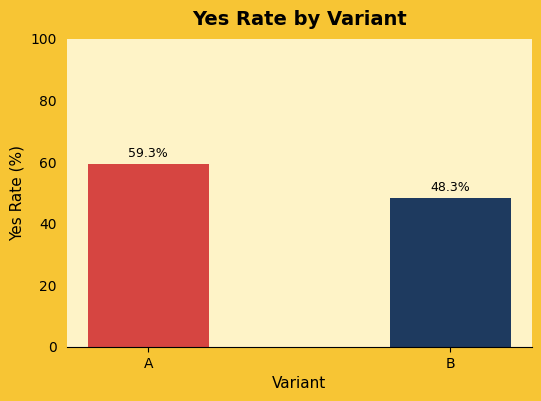

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

yes_rates = variant_analysis_v1.groupby('variant')['outcome'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(yes_rates.index, yes_rates.values,
                color=['#D64541', '#1E3A5F'],
                width=0.4, edgecolor='none')

ax.set_title('Yes Rate by Variant', fontsize=14, fontweight='bold', pad=10)
ax.set_ylabel('Yes Rate (%)', fontsize=11)
ax.set_xlabel('Variant', fontsize=11)
ax.set_ylim(0, 100)
ax.set_facecolor('#FEF3C7')
fig.patch.set_facecolor('#F7C534')

for bar, val in zip(bars, yes_rates.values):
      ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.tick_params(left=False)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.show()


In [42]:
variant_analysis_v1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 176 to 95
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_pseudo_id                56 non-null     float64
 1   variant                       56 non-null     object 
 2   event_timestamp               56 non-null     int64  
 3   cuisine_selected              55 non-null     object 
 4   price_selected                55 non-null     object 
 5   distance_selected             50 non-null     float64
 6   zip_code                      55 non-null     object 
 7   filters_changed_from_default  56 non-null     float64
 8   importance_cuisine            28 non-null     object 
 9   importance_price              28 non-null     object 
 10  importance_subway             28 non-null     object 
 11  outcome                       56 non-null     int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 5.7+ KB


In [43]:
# yes rate by variant
variant_analysis_v1.groupby('variant')['outcome'].mean()

,outcome
variant,
A,0.592593
B,0.482759


In [44]:
# table for chi-squared test
contingency_table_v1 =  variant_analysis_v1.groupby('variant')['outcome'].value_counts().unstack()
contingency_table_v1

outcome,0,1
variant,,
A,11,16
B,15,14


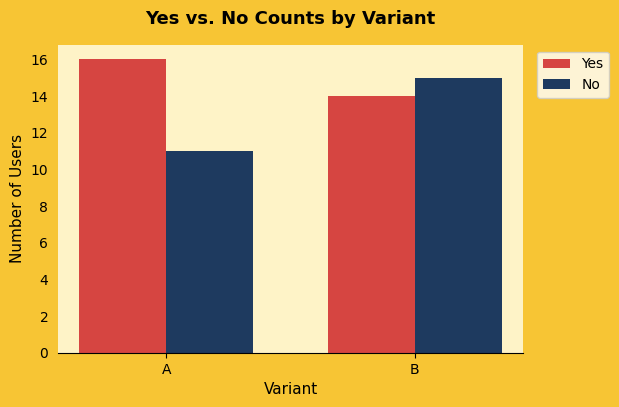

In [45]:
ct = contingency_table_v1.copy()
ct.columns = ['No', 'Yes']

x = range(len(ct.index))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([i - width/2 for i in x], ct['Yes'], width, label='Yes', color='#D64541', edgecolor='none')
ax.bar([i + width/2 for i in x], ct['No'], width, label='No', color='#1E3A5F', edgecolor='none')

ax.set_title('Yes vs. No Counts by Variant',
               fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Users', fontsize=11)
ax.set_xlabel('Variant', fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(ct.index)
ax.set_facecolor('#FEF3C7')
fig.patch.set_facecolor('#F7C534')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
ax.legend(loc='upper right', bbox_to_anchor=(1.20, 1))
plt.show()

In [46]:
#load in chi-squared test

import numpy as np
from scipy.stats import chi2_contingency

In [47]:
chi2, p, dof, expected = chi2_contingency(contingency_table_v1)

In [48]:
print(f"chi-square: {chi2:.4f}")
print(f"p-value: {p: .4f}")

# results are statistically insignificant

chi-square: 0.3085
p-value:  0.5786


Version 2: All spins included (non-deduplicated)

In [49]:
contingency_table_v2 = variant_analysis.groupby('variant')['outcome'].value_counts().unstack()
contingency_table_v2

outcome,0,1
variant,,
A,29,43
B,72,67


In [50]:
chi2, p, dof, expected = chi2_contingency(contingency_table_v2)
print(f"chi-square: {chi2:.4f}")
print(f"p-value: {p: .4f}")

chi-square: 2.0822
p-value:  0.1490


### Power Analysis
Need to see how many more users I would need to give feedback to get significant results. So far given the small effect size, would probably need a significantly higher amount of users to detect this effect size reliably.

In [51]:
from statsmodels.stats.power import GofChisquarePower
import math

In [57]:
# re-run chi-square on deduplicated data (one response per user)
chi2, p, dof, expected_table = chi2_contingency(contingency_table_v1)

# total feedback users
n_total = n_a + n_b

# Cohen's w to get an effect size and see how far observed results for a and b are from what we'd expect (under the null)
w = math.sqrt(chi2 / n_total)
print(f"Effect size (Cohen's w): {w:.4f}")



Effect size (Cohen's w): 0.0382


In [58]:
# Power analysis: how many users would we need to detect this effect reliably?
# 80% power, alpha=0.05

analysis = GofChisquarePower()
n_needed = analysis.solve_power(effect_size=w, alpha=0.05, power=0.80, n_bins=2)

print(f"Sample size needed per variant: {int(np.ceil(n_needed))}")
print(f"Total users needed: {int(np.ceil(n_needed)) * 2}")


Sample size needed per variant: 5370
Total users needed: 10740
